# Bank Marketing Classifier Comparison

Business objective: Predict whether a client will subscribe to a term deposit.

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score


## 2. Load Data

In [2]:
df = pd.read_csv('bank-additional-full.csv', sep=';')
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## 3. Data Understanding

In [3]:
df.info()
df.describe()
df['y'].value_counts(normalize=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

y
no     0.887346
yes    0.112654
Name: proportion, dtype: float64

## 4. Exploratory Data Analysis

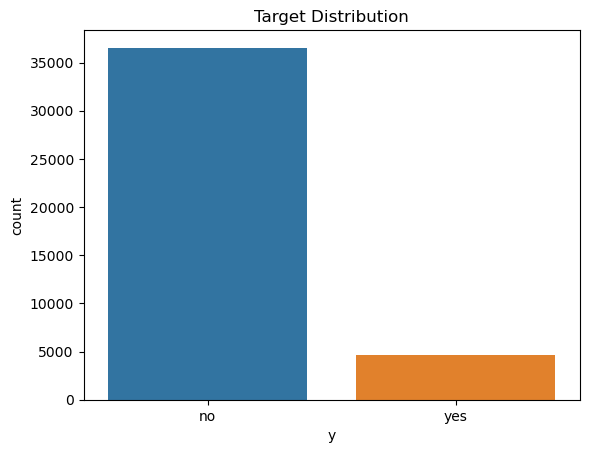

In [4]:
sns.countplot(data=df, x='y')
plt.title('Target Distribution')
plt.show()

In [5]:
Subscription Rate by Job

SyntaxError: invalid syntax (1826817547.py, line 1)

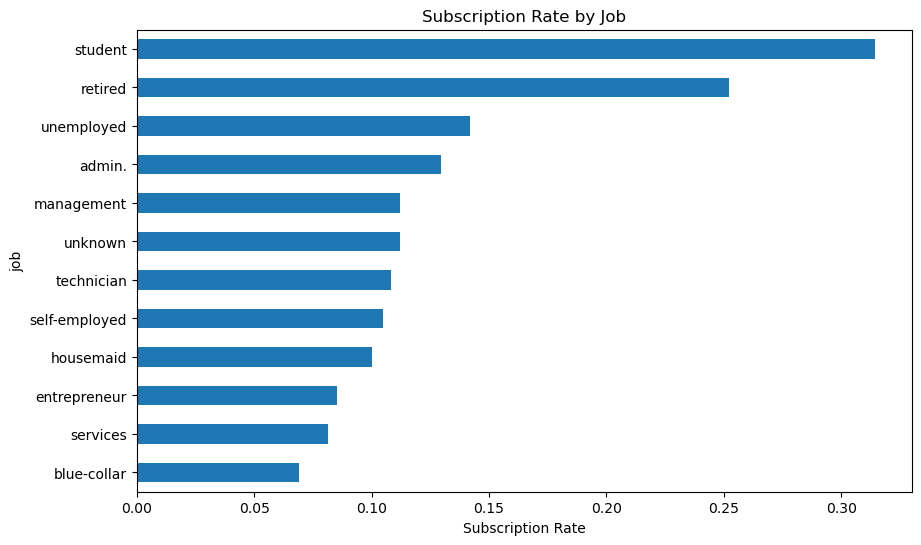

In [4]:
job_rate = (
    df.groupby('job')['y']
      .apply(lambda x: (x == 'yes').mean())
      .sort_values()
)

plt.figure(figsize=(10,6))
job_rate.plot(kind='barh')
plt.title('Subscription Rate by Job')
plt.xlabel('Subscription Rate')
plt.show()

In [ ]:
Subscription Rate by Month

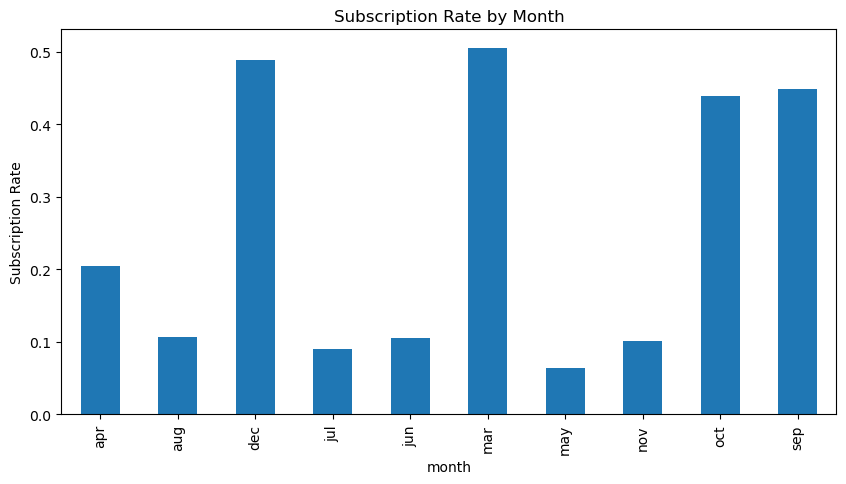

In [5]:
month_rate = (
    df.groupby('month')['y']
      .apply(lambda x: (x == 'yes').mean())
)

plt.figure(figsize=(10,5))
month_rate.plot(kind='bar')
plt.title('Subscription Rate by Month')
plt.ylabel('Subscription Rate')
plt.show()

In [ ]:
Age distribution

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


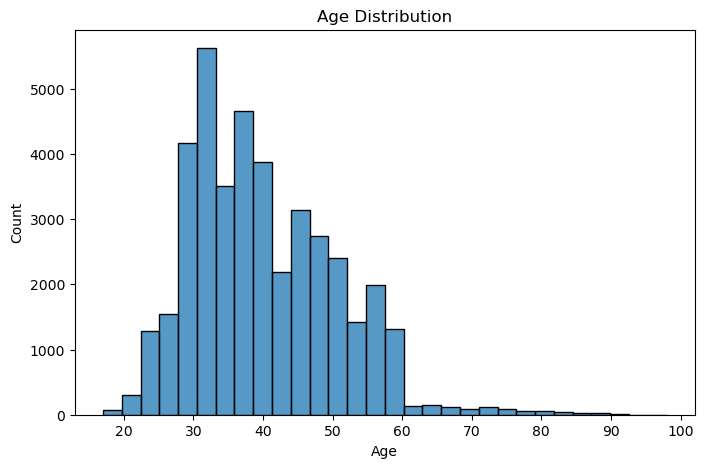

In [6]:
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=30)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.show()

In [ ]:
Correlation Heatmap

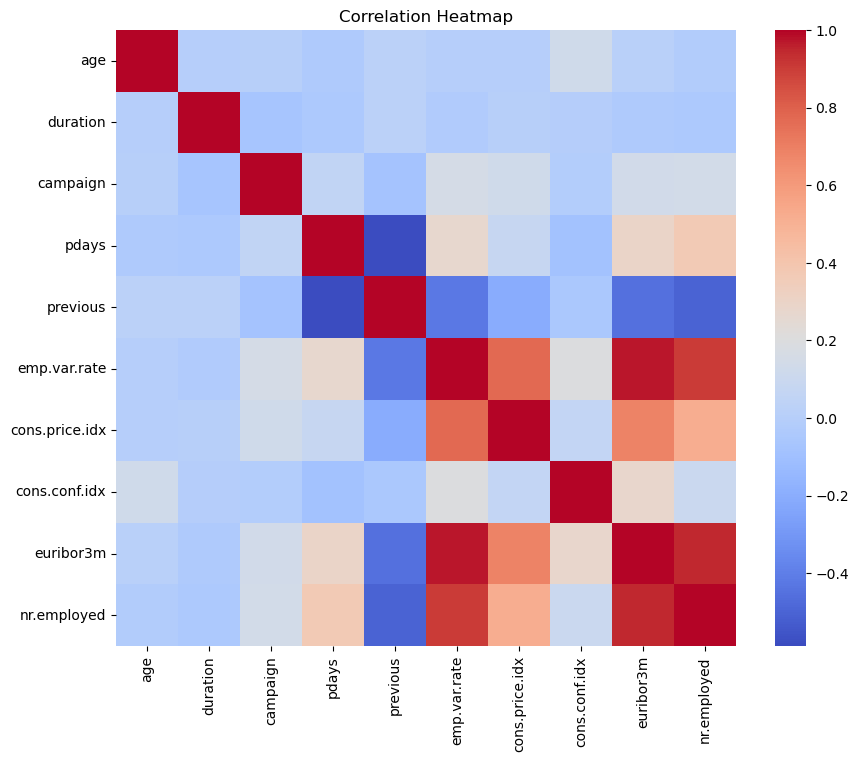

In [7]:
plt.figure(figsize=(10,8))

numeric_df = df.select_dtypes(include=['int64','float64'])

sns.heatmap(
    numeric_df.corr(),
    cmap='coolwarm',
    annot=False
)

plt.title('Correlation Heatmap')
plt.show()

In [ ]:
## Business Understanding

The objective of this project is to help a Portuguese banking institution improve the effectiveness of its direct marketing campaigns. The goal is to predict whether a customer will subscribe to a term deposit based on demographic, financial, campaign, and economic indicators.

A successful predictive model can help the bank prioritize high-probability customers, reduce unnecessary marketing calls, lower campaign costs, and improve conversion rates.


In [9]:
df_model = df.drop(columns=['duration'])

## 5. Data Preparation

In [12]:
df_model = df.drop(columns=['duration'])

X = df_model.drop(columns=['y'])
y = df_model['y'].map({'no':0,'yes':1})

categorical_cols = X.select_dtypes(include='object').columns
numeric_cols = X.select_dtypes(exclude='object').columns

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## 6. Model Comparison

In [13]:
models = {
    'KNN': KNeighborsClassifier(n_neighbors=5),

    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ),

    'Decision Tree': DecisionTreeClassifier(
        random_state=42,
        class_weight='balanced',
        max_depth=10
    ),

    'SVM': SVC(
        kernel='linear',
        probability=True,
        class_weight='balanced',
        random_state=42
    )
}

results = []

for name, model in models.items():

    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=3,
        scoring=['roc_auc', 'accuracy', 'precision', 'recall', 'f1'],
        n_jobs=-1
    )

    results.append({
        'Model': name,
        'ROC_AUC': scores['test_roc_auc'].mean(),
        'Accuracy': scores['test_accuracy'].mean(),
        'Precision': scores['test_precision'].mean(),
        'Recall': scores['test_recall'].mean(),
        'F1': scores['test_f1'].mean()
    })

results_df = pd.DataFrame(results)
results_df.sort_values('ROC_AUC', ascending=False)

,Model,ROC_AUC,Accuracy,Precision,Recall,F1
1,Logistic Regression,0.789788,0.826403,0.349355,0.624730,0.447982
3,SVM,0.766641,0.834628,0.360678,0.604526,0.451744
2,Decision Tree,0.730117,0.829165,0.344479,0.571652,0.429897
0,KNN,0.716618,0.890045,0.524893,0.277206,0.362569


## 7. Hyperparameter Tuning

In [14]:
pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ))
])

grid = GridSearchCV(
    pipe,
    {'model__C':[0.01,0.1,1,10]},
    cv=3,
    scoring='roc_auc',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best ROC-AUC:", grid.best_score_)

Best Parameters: {'model__C': 0.1}
Best ROC-AUC: 0.7900125201846372


## 8. Final Evaluation

In [15]:
pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ))
])

grid = GridSearchCV(
    pipe,
    {'model__C':[0.01,0.1,1,10]},
    cv=3,
    scoring='roc_auc',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best ROC-AUC:", grid.best_score_)

Best Parameters: {'model__C': 0.1}
Best ROC-AUC: 0.7900125201846372


In [16]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.95      0.86      0.90      7310
           1       0.37      0.65      0.47       928

    accuracy                           0.83      8238
   macro avg       0.66      0.75      0.68      8238
weighted avg       0.88      0.83      0.85      8238


Confusion Matrix:
[[6266 1044]
 [ 326  602]]

ROC-AUC: 0.8009255300957593


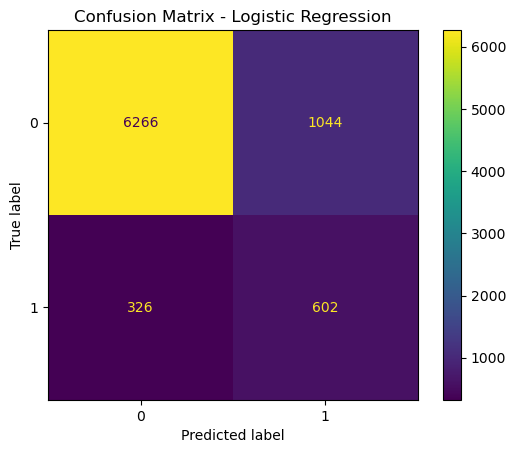

In [17]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

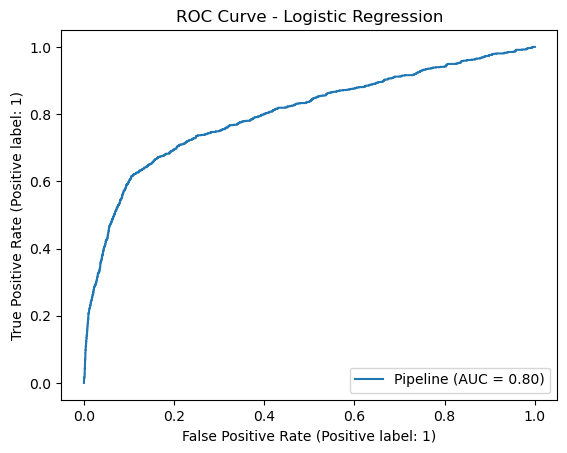

In [18]:
RocCurveDisplay.from_estimator(
    best_model,
    X_test,
    y_test
)

plt.title("ROC Curve - Logistic Regression")
plt.show()

## 9. Findings and Recommendations


The bank marketing dataset contains 41,188 customer records and exhibits significant class imbalance, with approximately 11% of customers subscribing to a term deposit.

Four classification models were evaluated:

- K-Nearest Neighbors
- Logistic Regression
- Decision Tree
- Support Vector Machine

Logistic Regression achieved the highest ROC-AUC score (0.790), indicating the strongest ability to distinguish between customers who subscribe and those who do not.

Although KNN achieved the highest accuracy, it demonstrated poor recall and would miss many potential subscribers. Because identifying likely subscribers is the primary business objective, ROC-AUC and recall were prioritized over accuracy.

The results indicate that customer demographic characteristics, prior campaign outcomes, and economic indicators provide useful predictive signals for subscription behavior.